In [42]:
import numpy as np
import pandas as pd
from scipy import stats
from tabulate import tabulate
import matplotlib.pyplot as plt
from astropy.io import fits
from astroquery.sdss import SDSS

np.random.seed(21)

# MANUAL TEST IMPLEMENTATIONS

In [43]:
# K-S Statistic (Dn): Maximum distance between ECDF and Normal CDF.
def manual_ks_test(data):

    x = np.sort(data)
    n = len(x)
    mean, std = np.mean(x), np.std(x, ddof=1)
    cdf_vals = stats.norm.cdf(x, loc=mean, scale=std)
    i = np.arange(1, n + 1)
    d_plus = i/n - cdf_vals
    d_minus = cdf_vals - (i-1)/n
    
    return np.max(np.maximum(d_plus, d_minus))

# A-D Statistic (A^2): Weighted distance focusing on tails.
def manual_anderson_darling(data):
    
    x = np.sort(data)
    n = len(x)
    mean, std = np.mean(x), np.std(x, ddof=1)
    z = (x - mean) / std
    f = stats.norm.cdf(z)
    f = np.clip(f, 1e-10, 1-1e-10) # Avoid log(0)
    i = np.arange(1, n + 1)
    sum_val = np.sum((2*i - 1) * np.log(f) + (2*n - 2*i + 1) * np.log(1 - f))

    return -n - (1/n) * sum_val

# Actual Shapiro-Wilk (W): Ratio of weighted linear combination 
def manual_shapiro_wilk(data):
    
    x = np.sort(data)
    n = len(x)
    mean = np.mean(x)
    # Approximation for weights ai (Normal Scores)
    m = stats.norm.ppf((np.arange(1, n + 1) - 0.375) / (n + 0.25))
    m_sum_sq = np.sum(m**2)
    a = m / np.sqrt(m_sum_sq)

    return (np.sum(a * x)**2) / np.sum((x - mean)**2)

# Pearson Chi-Sq: Comparing binned observed vs expected frequencies.
def manual_pearson_chisq(data, bins=15):

    n = len(data)
    mean, std = np.mean(data), np.std(data, ddof=1)
    observed, bin_edges = np.histogram(data, bins=bins)
    expected = []
    for i in range(len(bin_edges)-1):
        p_bin = stats.norm.cdf(bin_edges[i+1], mean, std) - stats.norm.cdf(bin_edges[i], mean, std)
        expected.append(p_bin * n)
    expected = np.array(expected)
    expected = np.where(expected == 0, 1e-10, expected)
    
    return np.sum((observed - expected)**2 / expected)


# RUNNER & PLOTTING

In [44]:
def run_gaussianity_tests(data, name):

    data = data[np.isfinite(data)] # Clean Data: Remove NaNs and Infs
    mean, std = np.mean(data), np.std(data)
    
    # Scipy for p-values & benchmarking
    ks_s, ks_p = stats.kstest(data, 'norm', args=(mean, std)) # Kolmogorov-Smirnov
    sw_data = data[:5000] if len(data) > 5000 else data               
    sw_s, sw_p = stats.shapiro(sw_data)                       # Shapiro-Wilk (limit to 5000 samples for performance/compatibility)
    ad_res = stats.anderson(data, dist='norm')                # Anderson-Darling
    pc_stat, pc_p = stats.normaltest(data)                    # Pearson Chi-Square (D'Agostino's K^2)
    
    # Manual Stats
    ks_m = manual_ks_test(data)                               # Manual Kolmogorov-Smirnov
    ad_m = manual_anderson_darling(data)                      # Manual Anderson-Darling
    sw_m = manual_shapiro_wilk(sw_data)                       # Manual Shapiro-Wilk
    pc_m = manual_pearson_chisq(data)                         # Manual Pearson Chi-Square
    
    # Table output
    results = [
        ["K-S Test", f"{ks_s:.4f}", f"{ks_m:.4f}", "Gaussian" if ks_p > 0.05 else "Non-Gaussian", f"delta={abs(ks_s - ks_m):.4g}"],
        ["Shapiro-Wilk", f"{sw_s:.4f}", f"{sw_m:.4f}", "Gaussian" if sw_p > 0.05 else "Non-Gaussian", f"delta={abs(sw_s - sw_m):.4g}"],
        ["Anderson-Darling", f"{ad_res.statistic:.4f}", f"{ad_m:.4f}", "Pass (Gaussian)" if ad_res.statistic < ad_res.critical_values[2] else "Fail (Non-Gaussian)", f"delta={abs(ad_res.statistic - ad_m):.4g}"],
        ["Pearson Chi-sq", f"{pc_stat:.4f}", f"{pc_m:.4f}", "Gaussian" if pc_p > 0.05 else "Non-Gaussian", f"delta={abs(pc_stat - pc_m):.4g}"]
    ]
    
    print(f"\n{name} Gaussianity Test Results:")
    print(tabulate(results, headers=["Test", "Scipy Stat", "Manual Stat", "Verdict (α=0.05)", "Delta"], tablefmt="grid"))
    
    # Plotting
    plt.figure(figsize=(10, 5))
    plt.hist(data, bins=50, density=True, alpha=0.6, color='seagreen', edgecolor='black', label='Data Histogram')
    x = np.linspace(min(data), max(data), 200)
    plt.plot(x, stats.norm.pdf(x, mean, std), 'r-', lw=2, label='Theoretical Gaussian')
    plt.title(f"Gaussianity Check: {name}\n")
    plt.xlabel("Value"), plt.ylabel("Density"), plt.legend(), plt.grid(alpha=0.3)
    plt.show()



# DATA ACQUISITION

In [45]:
# Gaussian Case: Fetches a LOW-RES actual Planck CMB map (faster).
def get_cmb_data():

    print("Streaming Low-Res CMB Data (Planck LFI)...")

    url = "https://irsa.ipac.caltech.edu/data/Planck/release_3/all-sky-maps/maps/LFI_SkyMap_030_1024_R3.00_full.fits"
    
    with fits.open(url, cache=True) as hdul:    # cache=True
        map_data = hdul[1].data['I_STOKES']
        clean_data = map_data[np.isfinite(map_data)]
        l = len(clean_data) # 12582912
        print(f"Total: {l} valid CMB pixels, using a central slice of 3000 pixels for testing.")
        clean_data = clean_data[l//2:l//2 + 3000] # taking a central slice of 3000 pixels for testing
        mean, std = np.mean(clean_data), np.std(clean_data)
        processed_data = (clean_data - mean) / std 
        
        return processed_data 
            
# Non-Gaussian: SDSS Galaxy Redshifts.
def get_sdss_redshifts():
    
    print("Fetching SDSS Redshifts...")
    l = 50000 # limit is 500000 
    query = f"SELECT TOP {l} z FROM SpecObj WHERE class = 'GALAXY' AND z > 0.01"
    res = SDSS.query_sql(query)

    return np.array(res['z'])

Streaming Low-Res CMB Data (Planck LFI)...
Total: 12582912 valid CMB pixels, using a central slice of 3000 pixels for testing.
Fetching SDSS Redshifts...

Planck CMB (Gaussian Case) Gaussianity Test Results:
+------------------+--------------+---------------+--------------------+-----------------+
| Test             |   Scipy Stat |   Manual Stat | Verdict (α=0.05)   | Delta           |
+==================+==============+===============+====================+=================+
| K-S Test         |       0.0094 |        0.0094 | Gaussian           | delta=2.89e-05  |
+------------------+--------------+---------------+--------------------+-----------------+
| Shapiro-Wilk     |       0.9996 |        0.9997 | Gaussian           | delta=5.63e-05  |
+------------------+--------------+---------------+--------------------+-----------------+
| Anderson-Darling |       0.2211 |        0.2211 | Pass (Gaussian)    | delta=4.177e-08 |
+------------------+--------------+---------------+-------------

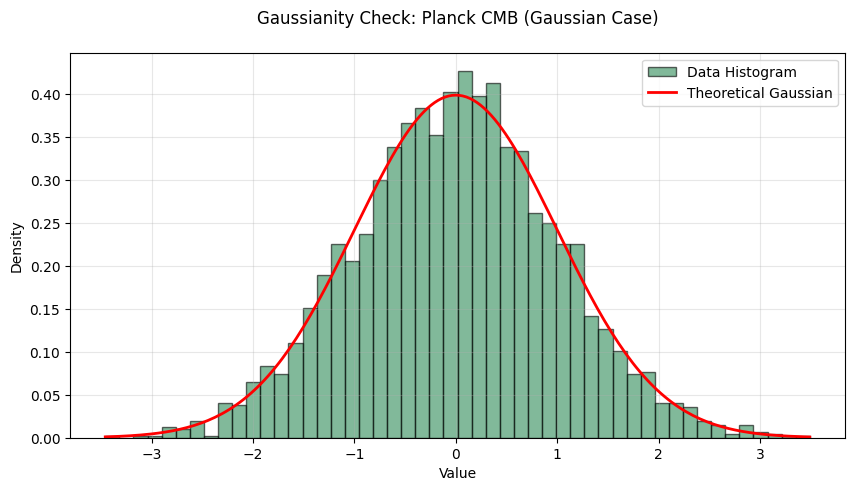


SDSS Redshifts (Non-Gaussian Case) Gaussianity Test Results:
+------------------+--------------+---------------+---------------------+-----------------+
| Test             |   Scipy Stat |   Manual Stat | Verdict (α=0.05)    | Delta           |
+==================+==============+===============+=====================+=================+
| K-S Test         |       0.0743 |        0.0743 | Non-Gaussian        | delta=2.03e-06  |
+------------------+--------------+---------------+---------------------+-----------------+
| Shapiro-Wilk     |       0.9423 |        0.9427 | Non-Gaussian        | delta=0.0003844 |
+------------------+--------------+---------------+---------------------+-----------------+
| Anderson-Darling |     647.693  |      647.693  | Fail (Non-Gaussian) | delta=7.276e-12 |
+------------------+--------------+---------------+---------------------+-----------------+
| Pearson Chi-sq   |    3584.95   |    11126.2    | Non-Gaussian        | delta=7541      |
+-----------------

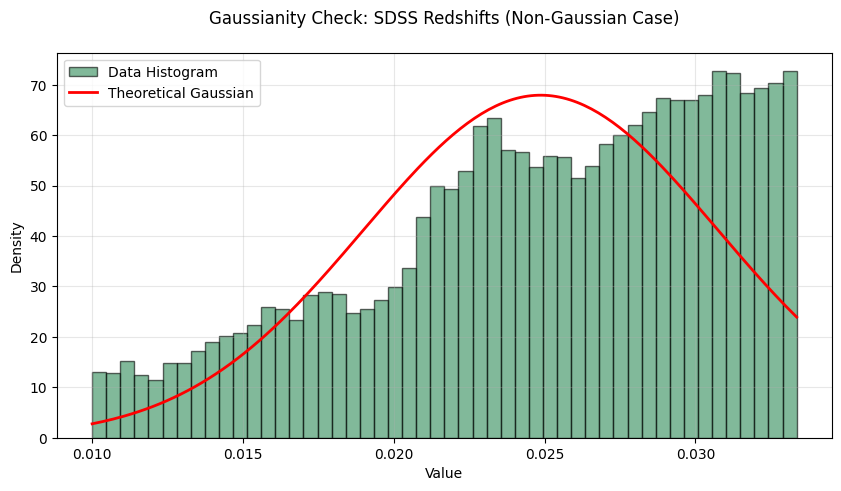

In [46]:
datasets = [(get_cmb_data(), "Planck CMB (Gaussian Case)"), 
            (get_sdss_redshifts(), "SDSS Redshifts (Non-Gaussian Case)")
            ]

for data, name in datasets:
    run_gaussianity_tests(data, name)